# Benchmark ma trận: BM25S vs BM25-PT theo `doc_size × query_size`

Notebook này mở rộng benchmark hiện tại từ **một cấu hình cố định** sang **nhiều kích thước corpus và nhiều kích thước batch query**.

Mục tiêu đo:

| Phase | Ý nghĩa |
|---|---|
| `index_total_s` | Thời gian build index theo từng `doc_size` |
| `search_total_s_mean` | Thời gian search trung bình cho `query_size` queries |
| `avg_ms_per_query_mean` | Latency trung bình trên mỗi query trong batch |
| `qps_mean` | Throughput, số queries/giây |
| `speedup_bm25s_vs_bm25pt` | `BM25-PT time / BM25S time`; > 1 nghĩa là BM25S nhanh hơn |

**Lưu ý quan trọng:** trong notebook này, `query_size` được hiểu là **số lượng queries trong batch**, không phải độ dài query theo số token. Nếu muốn benchmark theo độ dài query, xem phần mở rộng cuối notebook.


---
## 0. Cài đặt & import


In [1]:
!pip install -q ir_datasets bm25s bm25_pt PyStemmer matplotlib seaborn pandas tqdm

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 16.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 752.4/752.4 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 105.0 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-c

In [2]:
import os
import gc
import time
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import ir_datasets
import bm25s
import Stemmer
import torch
from bm25_pt import BM25 as BM25PT

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print("✅ Imports done")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


✅ Imports done
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


---
## 1. Cấu hình benchmark

Bạn chỉ cần chỉnh các biến trong cell này.


In [33]:

# ============================================================
# Dataset
# ============================================================
CORPUS_ID = "msmarco-passage"
EVAL_ID   = "msmarco-passage/dev/small"

# Nếu chạy trên Kaggle với dataset đã add sẵn, giữ dòng copy này.
# Nếu chạy local và ir_datasets đã tải dữ liệu rồi, có thể đặt COPY_KAGGLE_DATASET = False.
COPY_KAGGLE_DATASET = True
KAGGLE_MSMARCO_PATH = "/kaggle/input/datasets/hongkimgip/msmarco-passage/msmarco-passage"
IR_DATASETS_TARGET  = "/root/.ir_datasets/msmarco-passage"

# ============================================================
# Ma trận kích thước cần benchmark
# ============================================================
# Nên tăng dần. Với BM25-PT, đừng đưa size quá lớn nếu chạy GPU nhỏ.
DOC_SIZES = [1_000, 5_000, 10_000, 50_000, 100_000, 1_000_000, 8_000_000]
# DOC_SIZES = [1_000]

# query_size ở đây = số lượng queries trong batch search.
QUERY_SIZES = [500]

TOP_K = 100

# Search lặp lại để giảm nhiễu thời gian.
# Indexing thường tốn kém nên mặc định đo 1 lần / doc_size / engine.
SEARCH_WARMUP_RUNS = 1
SEARCH_REPEATS = 3

# ============================================================
# BM25S config
# ============================================================
BM25S_K1 = 1.5
BM25S_B = 0.75
BM25S_METHOD = "lucene"
BM25S_STEMMER_LANG = "english"    # hoặc None
BM25S_STOPWORDS = "english"       # hoặc None

# ============================================================
# BM25-PT config
# ============================================================
BM25PT_K1 = 1.5
BM25PT_B = 0.75

# Để so sánh CPU-CPU công bằng, để 'cpu'.
# Nếu muốn thử khả năng GPU của BM25-PT, đổi thành 'cuda' hoặc 'auto', nhưng nên báo cáo riêng.
BM25PT_DEVICE = "auto"             # 'cpu' | 'cuda' | 'auto'
BM25PT_CUDA_DOC_LIMIT = 8_000_000
BM25PT_FORCE_CPU_IF_LARGE = True

BM25PT_TOKENIZER = None            # None = tokenizer mặc định của bm25_pt, thường là bert-base-uncased
BM25PT_INTERNAL_QUERY_BATCH_SIZE = 128  # batch/chunk nội bộ khi gọi score_batch

# ============================================================
# Output
# ============================================================
OUTPUT_DIR = Path("benchmark_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("📌 Benchmark grid")
print("DOC_SIZES:", DOC_SIZES)
print("QUERY_SIZES:", QUERY_SIZES)
print("TOP_K:", TOP_K)
print("BM25PT_DEVICE:", BM25PT_DEVICE)


📌 Benchmark grid
DOC_SIZES: [1000, 5000, 10000, 50000, 100000, 1000000, 8000000]
QUERY_SIZES: [500]
TOP_K: 100
BM25PT_DEVICE: auto


---
## 2. Chuẩn bị dữ liệu

Ta chỉ load tối đa `max(DOC_SIZES)` documents và `max(QUERY_SIZES)` queries một lần, sau đó lấy prefix subset cho từng cấu hình benchmark.


In [4]:

if COPY_KAGGLE_DATASET and os.path.exists(KAGGLE_MSMARCO_PATH):
    os.makedirs(os.path.dirname(IR_DATASETS_TARGET), exist_ok=True)
    if not os.path.exists(IR_DATASETS_TARGET):
        print("📦 Copy MSMARCO dataset vào ir_datasets cache...")
        os.system(f"cp -r {KAGGLE_MSMARCO_PATH} {IR_DATASETS_TARGET}")
    else:
        print("✅ ir_datasets cache đã tồn tại, bỏ qua copy.")
else:
    print("ℹ️ Không copy Kaggle dataset. Sẽ dùng dữ liệu hiện có của ir_datasets.")


📦 Copy MSMARCO dataset vào ir_datasets cache...


In [30]:

MAX_DOCS_TO_LOAD = max(DOC_SIZES)
MAX_QUERIES_TO_LOAD = max(QUERY_SIZES)

print("========== LOADING CORPUS ==========")
passages_ds = ir_datasets.load(CORPUS_ID)

all_doc_ids = []
all_texts = []

for doc in tqdm(passages_ds.docs_iter(), total=MAX_DOCS_TO_LOAD, desc="Loading passages"):
    all_doc_ids.append(doc.doc_id)
    all_texts.append(doc.text)
    if len(all_doc_ids) >= MAX_DOCS_TO_LOAD:
        break

print(f"✅ Loaded docs: {len(all_texts):,}")

print("\n========== LOADING QUERIES ==========")
eval_ds = ir_datasets.load(EVAL_ID)

all_query_ids = []
all_query_texts = []

for query in tqdm(eval_ds.queries_iter(), total=MAX_QUERIES_TO_LOAD, desc="Loading queries"):
    all_query_ids.append(query.query_id)
    all_query_texts.append(query.text)
    if len(all_query_texts) >= MAX_QUERIES_TO_LOAD:
        break

print(f"✅ Loaded queries: {len(all_query_texts):,}")

# Lọc lại nếu dataset thực tế ít hơn cấu hình
DOC_SIZES = [n for n in DOC_SIZES if n <= len(all_texts)]
QUERY_SIZES = [n for n in QUERY_SIZES if n <= len(all_query_texts)]

print("\n📌 Effective grid after filtering")
print("DOC_SIZES:", DOC_SIZES)
print("QUERY_SIZES:", QUERY_SIZES)

print("\nSample doc:", all_texts[0][:160], "...")
print("Sample query:", all_query_texts[0])


========== LOADING CORPUS ==========


Loading passages:   0%|          | 0/8000000 [00:00<?, ?it/s]

✅ Loaded docs: 8,000,000

========== LOADING QUERIES ==========


Loading queries:   0%|          | 0/500 [00:00<?, ?it/s]

✅ Loaded queries: 500

📌 Effective grid after filtering
DOC_SIZES: [1000, 5000, 10000, 50000, 100000, 1000000, 8000000]
QUERY_SIZES: [500]

Sample doc: The presence of communication amid scientific minds was equally important to the success of the Manhattan Project as scientific intellect was. The only cloud ha ...
Sample query: what is paula deen's brother


---
## 3. Utility functions


In [31]:

def sync_if_cuda(device: str | None = None):
    """Đồng bộ CUDA trước/sau khi đo thời gian để tránh đo thiếu async kernel."""
    if torch.cuda.is_available() and (device is None or str(device).startswith("cuda")):
        torch.cuda.synchronize()


def cleanup_memory():
    """Giải phóng RAM/GPU cache giữa các cấu hình."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass


def format_seconds(seconds: float) -> str:
    if seconds < 1:
        return f"{seconds * 1000:.2f} ms"
    if seconds < 60:
        return f"{seconds:.2f} s"
    m, s = divmod(seconds, 60)
    return f"{int(m)}m {s:.1f}s"


def time_once(fn, device: str | None = None):
    """Đo một lần, có sync CUDA nếu cần."""
    cleanup_memory()
    sync_if_cuda(device)
    t0 = time.perf_counter()
    out = fn()
    sync_if_cuda(device)
    elapsed = time.perf_counter() - t0
    return out, elapsed


def summarize_repeated_measurements(records: list[dict]) -> dict:
    """records là list các dict cùng key số học."""
    if not records:
        return {}
    keys = records[0].keys()
    summary = {}
    for k in keys:
        vals = np.array([r[k] for r in records], dtype=float)
        summary[f"{k}_mean"] = float(vals.mean())
        summary[f"{k}_std"] = float(vals.std(ddof=0))
        summary[f"{k}_min"] = float(vals.min())
        summary[f"{k}_max"] = float(vals.max())
    return summary


def resolve_bm25pt_device(num_docs: int) -> str:
    if BM25PT_DEVICE == "auto":
        device = "cuda" if torch.cuda.is_available() else "cpu"
    else:
        device = BM25PT_DEVICE

    if (
        BM25PT_FORCE_CPU_IF_LARGE
        and device.startswith("cuda")
        and num_docs > BM25PT_CUDA_DOC_LIMIT
    ):
        print(
            f"⚠️ doc_size={num_docs:,} > BM25PT_CUDA_DOC_LIMIT={BM25PT_CUDA_DOC_LIMIT:,}. "
            "Fallback BM25-PT về CPU để tránh CUDA OOM."
        )
        device = "cpu"
    return device


# Tokenizer object cho BM25-PT, load một lần nếu user cấu hình tokenizer HF cụ thể.
if BM25PT_TOKENIZER is not None and isinstance(BM25PT_TOKENIZER, str):
    from transformers import AutoTokenizer
    bm25pt_tokenizer_obj = AutoTokenizer.from_pretrained(BM25PT_TOKENIZER)
    bm25pt_tokenizer_name = BM25PT_TOKENIZER
else:
    bm25pt_tokenizer_obj = BM25PT_TOKENIZER
    bm25pt_tokenizer_name = "default"

print("✅ Utility functions ready")


✅ Utility functions ready


---
## 4. Hàm build/search cho từng engine


In [7]:

def build_bm25s_index(texts_subset: list[str]) -> tuple[object, dict]:
    """Build BM25S index và trả về retriever + timing dict."""
    stemmer = Stemmer.Stemmer(BM25S_STEMMER_LANG) if BM25S_STEMMER_LANG else None

    def tokenize_docs():
        return bm25s.tokenize(texts_subset, stopwords=BM25S_STOPWORDS, stemmer=stemmer)

    corpus_tokens, tokenization_time = time_once(tokenize_docs, device="cpu")

    retriever = bm25s.BM25(k1=BM25S_K1, b=BM25S_B, method=BM25S_METHOD)
    _, indexing_time = time_once(lambda: retriever.index(corpus_tokens), device="cpu")

    timings = {
        "index_tokenization_s": tokenization_time,
        "index_core_s": indexing_time,
        "index_total_s": tokenization_time + indexing_time,
    }
    return retriever, timings


def search_bm25s(retriever, query_texts_subset: list[str]) -> dict:
    """Search BM25S end-to-end: query tokenization + retrieve top-k."""
    stemmer = Stemmer.Stemmer(BM25S_STEMMER_LANG) if BM25S_STEMMER_LANG else None

    t0 = time.perf_counter()
    query_tokens = bm25s.tokenize(query_texts_subset, stopwords=BM25S_STOPWORDS, stemmer=stemmer)
    tokenization_s = time.perf_counter() - t0

    t1 = time.perf_counter()
    _results, _scores = retriever.retrieve(query_tokens, k=TOP_K)
    retrieval_s = time.perf_counter() - t1

    total_s = tokenization_s + retrieval_s
    n_queries = len(query_texts_subset)

    return {
        "search_tokenization_s": tokenization_s,
        "search_retrieval_s": retrieval_s,
        "search_total_s": total_s,
        "avg_ms_per_query": (total_s / n_queries) * 1000,
        "qps": n_queries / total_s if total_s > 0 else np.inf,
    }


def build_bm25pt_index(texts_subset: list[str], device: str) -> tuple[object, dict]:
    """Build BM25-PT index. Tokenization nằm bên trong BM25PT.index."""
    bm25pt_kwargs = {
        "k1": BM25PT_K1,
        "b": BM25PT_B,
        "device": device,
    }
    if bm25pt_tokenizer_obj is not None:
        bm25pt_kwargs["tokenizer"] = bm25pt_tokenizer_obj

    retriever = BM25PT(**bm25pt_kwargs)

    try:
        _, index_total_s = time_once(lambda: retriever.index(texts_subset), device=device)
    except RuntimeError as e:
        cleanup_memory()
        if "out of memory" in str(e).lower():
            raise RuntimeError(
                f"CUDA/RAM OOM khi build BM25-PT với doc_size={len(texts_subset):,}. "
                "Hãy giảm DOC_SIZES, đặt BM25PT_DEVICE='cpu', hoặc giảm BM25PT_CUDA_DOC_LIMIT."
            ) from e
        raise

    timings = {
        "index_tokenization_s": np.nan,  # BM25-PT gộp tokenization trong index()
        "index_core_s": index_total_s,
        "index_total_s": index_total_s,
    }
    return retriever, timings


def search_bm25pt(retriever, query_texts_subset: list[str], device: str, doc_size: int) -> dict:
    """Search BM25-PT end-to-end: score_batch + top-k extraction, chia chunk để tránh score matrix quá lớn."""
    total_s = 0.0
    n_queries = len(query_texts_subset)

    for start in range(0, n_queries, BM25PT_INTERNAL_QUERY_BATCH_SIZE):
        end = min(start + BM25PT_INTERNAL_QUERY_BATCH_SIZE, n_queries)
        q_batch = query_texts_subset[start:end]

        cleanup_memory()
        sync_if_cuda(device)
        t0 = time.perf_counter()
        with torch.no_grad():
            scores = retriever.score_batch(q_batch, batch_size=len(q_batch))
            if device.startswith("cuda"):
                torch.cuda.synchronize()

            # Top-k extraction để so với BM25S.retrieve(k=TOP_K), nhưng không giữ kết quả lại.
            _topk_scores, _topk_indices = torch.topk(
                scores,
                k=min(TOP_K, scores.shape[1]),
                dim=1,
            )
            if device.startswith("cuda"):
                torch.cuda.synchronize()

        total_s += time.perf_counter() - t0

        del scores, _topk_scores, _topk_indices
        cleanup_memory()

    return {
        "search_tokenization_s": np.nan,  # BM25-PT gộp tokenization trong score_batch()
        "search_retrieval_s": total_s,
        "search_total_s": total_s,
        "avg_ms_per_query": (total_s / n_queries) * 1000,
        "qps": n_queries / total_s if total_s > 0 else np.inf,
    }


---
## 5. Chạy benchmark ma trận

Chiến lược chạy:

1. Với mỗi `doc_size`, lấy prefix `all_texts[:doc_size]`.
2. Build index BM25S một lần, sau đó search lần lượt các `query_size`.
3. Xóa index BM25S khỏi RAM.
4. Build index BM25-PT một lần, sau đó search lần lượt các `query_size`.
5. Xóa index BM25-PT khỏi RAM/GPU.


In [34]:

benchmark_rows = []

for doc_size in DOC_SIZES:
    print("\n" + "=" * 90)
    print(f"📄 DOC SIZE = {doc_size:,}")
    print("=" * 90)

    texts_subset = all_texts[:doc_size]

    # ------------------------------------------------------------
    # BM25S
    # ------------------------------------------------------------
    print("\n🔵 Building BM25S index...")
    bm25s_retriever, bm25s_index_timing = build_bm25s_index(texts_subset)
    print("BM25S index total:", format_seconds(bm25s_index_timing["index_total_s"]))

    for query_size in QUERY_SIZES:
        query_subset = all_query_texts[:query_size]
        print(f"  🔎 BM25S search | query_size={query_size:,}")

        # warmup
        for _ in range(SEARCH_WARMUP_RUNS):
            _ = search_bm25s(bm25s_retriever, query_subset)

        repeated = []
        for _ in range(SEARCH_REPEATS):
            repeated.append(search_bm25s(bm25s_retriever, query_subset))

        search_summary = summarize_repeated_measurements(repeated)

        benchmark_rows.append({
            "engine": "bm25s",
            "doc_size": doc_size,
            "query_size": query_size,
            "top_k": TOP_K,
            "device": "cpu",
            "index_tokenization_s": bm25s_index_timing["index_tokenization_s"],
            "index_core_s": bm25s_index_timing["index_core_s"],
            "index_total_s": bm25s_index_timing["index_total_s"],
            **search_summary,
        })

    del bm25s_retriever
    cleanup_memory()

    # ------------------------------------------------------------
    # BM25-PT
    # ------------------------------------------------------------
    bm25pt_device = resolve_bm25pt_device(doc_size)
    print(f"\n🔴 Building BM25-PT index... device={bm25pt_device}")
    bm25pt_retriever, bm25pt_index_timing = build_bm25pt_index(texts_subset, bm25pt_device)
    print("BM25-PT index total:", format_seconds(bm25pt_index_timing["index_total_s"]))

    for query_size in QUERY_SIZES:
        query_subset = all_query_texts[:query_size]
        print(f"  🔎 BM25-PT search | query_size={query_size:,}")

        # warmup
        for _ in range(SEARCH_WARMUP_RUNS):
            _ = search_bm25pt(bm25pt_retriever, query_subset, bm25pt_device, doc_size)

        repeated = []
        for _ in range(SEARCH_REPEATS):
            repeated.append(search_bm25pt(bm25pt_retriever, query_subset, bm25pt_device, doc_size))

        search_summary = summarize_repeated_measurements(repeated)

        benchmark_rows.append({
            "engine": "bm25_pt",
            "doc_size": doc_size,
            "query_size": query_size,
            "top_k": TOP_K,
            "device": bm25pt_device,
            "index_tokenization_s": bm25pt_index_timing["index_tokenization_s"],
            "index_core_s": bm25pt_index_timing["index_core_s"],
            "index_total_s": bm25pt_index_timing["index_total_s"],
            **search_summary,
        })

    del bm25pt_retriever
    cleanup_memory()

print("\n✅ Benchmark completed")



📄 DOC SIZE = 1,000

🔵 Building BM25S index...


Split strings:   0%|          | 0/1000 [00:00<?, ?it/s]

Stem Tokens:   0%|          | 0/1000 [00:00<?, ?it/s]

BM25S Count Tokens:   0%|          | 0/1000 [00:00<?, ?it/s]

BM25S Compute Scores:   0%|          | 0/1000 [00:00<?, ?it/s]

...

BM25S Retrieve:   0%|          | 0/500 [00:00<?, ?it/s]


🔴 Building BM25-PT index... device=cuda


  0%|          | 0/1000000 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (524 > 512). Running this sequence through the model will result in indexing errors


RuntimeError: CUDA/RAM OOM khi build BM25-PT với doc_size=1,000,000. Hãy giảm DOC_SIZES, đặt BM25PT_DEVICE='cpu', hoặc giảm BM25PT_CUDA_DOC_LIMIT.

---
## 6. Lưu và xem bảng kết quả


In [35]:

df = pd.DataFrame(benchmark_rows)

# Sắp xếp cột cho dễ đọc
preferred_cols = [
    "engine", "device", "doc_size", "query_size", "top_k",
    "index_total_s", "index_tokenization_s", "index_core_s",
    "search_total_s_mean", "search_total_s_std",
    "avg_ms_per_query_mean", "avg_ms_per_query_std",
    "qps_mean", "qps_std",
    "search_tokenization_s_mean", "search_retrieval_s_mean",
]
other_cols = [c for c in df.columns if c not in preferred_cols]
df = df[preferred_cols + other_cols]

display(df)

csv_path = OUTPUT_DIR / "benchmark_bm25s_vs_bm25pt_matrix.csv"
json_path = OUTPUT_DIR / "benchmark_bm25s_vs_bm25pt_matrix.json"

config = {
    "corpus_id": CORPUS_ID,
    "eval_id": EVAL_ID,
    "doc_sizes": DOC_SIZES,
    "query_sizes": QUERY_SIZES,
    "top_k": TOP_K,
    "search_warmup_runs": SEARCH_WARMUP_RUNS,
    "search_repeats": SEARCH_REPEATS,
    "bm25s": {
        "k1": BM25S_K1,
        "b": BM25S_B,
        "method": BM25S_METHOD,
        "stemmer_lang": BM25S_STEMMER_LANG,
        "stopwords": BM25S_STOPWORDS,
    },
    "bm25_pt": {
        "k1": BM25PT_K1,
        "b": BM25PT_B,
        "device": BM25PT_DEVICE,
        "tokenizer": bm25pt_tokenizer_name,
        "internal_query_batch_size": BM25PT_INTERNAL_QUERY_BATCH_SIZE,
        "cuda_doc_limit": BM25PT_CUDA_DOC_LIMIT,
        "force_cpu_if_large": BM25PT_FORCE_CPU_IF_LARGE,
    },
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
}

df.to_csv(csv_path, index=False)
with open(json_path, "w", encoding="utf-8") as f:
    json.dump({"config": config, "results": df.to_dict(orient="records")}, f, ensure_ascii=False, indent=2)

print(f"💾 Saved CSV:  {csv_path}")
print(f"💾 Saved JSON: {json_path}")


,engine,device,doc_size,query_size,top_k,index_total_s,index_tokenization_s,index_core_s,search_total_s_mean,search_total_s_std,avg_ms_per_query_mean,avg_ms_per_query_std,qps_mean,qps_std,search_tokenization_s_mean,search_retrieval_s_mean,search_tokenization_s_std,search_tokenization_s_min,search_tokenization_s_max,search_retrieval_s_std,search_retrieval_s_min,search_retrieval_s_max,search_total_s_min,search_total_s_max,avg_ms_per_query_min,avg_ms_per_query_max,qps_min,qps_max
0,bm25s,cpu,1000,500,100,0.128428,0.067896,0.060532,0.477319,0.003315,0.954638,0.006631,1047.568255,7.257571,0.026493,0.450826,0.001316,0.024810,0.028024,0.003031,0.448420,0.455102,0.473767,0.481746,0.947535,0.963491,1037.892005,1055.370521
1,bm25_pt,cuda,1000,500,100,0.361152,NaN,0.361152,0.042296,0.000470,0.084592,0.000940,11822.873184,130.729521,NaN,0.042296,NaN,NaN,NaN,0.000470,0.041813,0.042933,0.041813,0.042933,0.083627,0.085866,11645.990492,11957.894531
2,bm25s,cpu,5000,500,100,0.440616,0.210896,0.229720,0.525868,0.009549,1.051736,0.019098,951.122252,17.278446,0.026009,0.499859,0.001413,0.024063,0.027377,0.008568,0.490077,0.510944,0.514140,0.537530,1.028280,1.075060,930.180684,972.497396
3,bm25_pt,cuda,5000,500,100,1.717670,NaN,1.717670,0.052603,0.000860,0.105205,0.001720,9507.754678,154.174256,NaN,0.052603,NaN,NaN,NaN,0.000860,0.051751,0.053780,0.051751,0.053780,0.103502,0.107561,9297.055059,9661.672014
4,bm25s,cpu,10000,500,100,0.704488,0.373846,0.330641,0.540297,0.015978,1.080595,0.031955,926.210007,26.836835,0.024732,0.515566,0.001000,0.023339,0.025642,0.015612,0.504468,0.537643,0.527924,0.562858,1.055848,1.125715,888.324033,947.105759
5,bm25_pt,cuda,10000,500,100,3.456003,NaN,3.456003,0.069153,0.001024,0.138306,0.002049,7231.911989,106.562435,NaN,0.069153,NaN,NaN,NaN,0.001024,0.068047,0.070516,0.068047,0.070516,0.136095,0.141033,7090.550054,7347.824929
6,bm25s,cpu,50000,500,100,3.397597,1.658309,1.739288,0.643648,0.024654,1.287297,0.049308,777.933130,29.015177,0.025595,0.618053,0.000682,0.024661,0.026270,0.024167,0.600645,0.652228,0.625307,0.678498,1.250613,1.356996,736.921682,799.607853
7,bm25_pt,cuda,50000,500,100,17.750887,NaN,17.750887,0.198736,0.000165,0.397473,0.000330,2515.897812,2.092504,NaN,0.198736,NaN,NaN,NaN,0.000165,0.198506,0.198885,0.198506,0.198885,0.397012,0.397770,2514.016168,2518.816618
8,bm25s,cpu,100000,500,100,7.499376,3.135898,4.363478,0.716122,0.021507,1.432243,0.043015,698.837582,21.052251,0.026132,0.689990,0.003245,0.023041,0.030614,0.020933,0.666191,0.717136,0.689232,0.741877,1.378463,1.483755,673.965919,725.445434
9,bm25_pt,cuda,100000,500,100,35.338945,NaN,35.338945,0.354547,0.001829,0.709093,0.003658,1410.289222,7.263791,NaN,0.354547,NaN,NaN,NaN,0.001829,0.352542,0.356965,0.352542,0.356965,0.705084,0.713930,1400.698022,1418.270831


💾 Saved CSV:  benchmark_outputs/benchmark_bm25s_vs_bm25pt_matrix.csv
💾 Saved JSON: benchmark_outputs/benchmark_bm25s_vs_bm25pt_matrix.json


---
## 7. Tính speedup BM25S vs BM25-PT

Công thức:

\[
\text{speedup\_bm25s\_vs\_bm25pt} = \frac{\text{BM25-PT search time}}{\text{BM25S search time}}
\]

- `> 1`: BM25S nhanh hơn.
- `< 1`: BM25-PT nhanh hơn.


In [36]:

search_pivot = df.pivot_table(
    index=["doc_size", "query_size"],
    columns="engine",
    values="search_total_s_mean",
    aggfunc="mean",
).reset_index()

search_pivot["speedup_bm25s_vs_bm25pt"] = search_pivot["bm25_pt"] / search_pivot["bm25s"]
search_pivot["winner_search"] = np.where(
    search_pivot["speedup_bm25s_vs_bm25pt"] > 1,
    "bm25s",
    "bm25_pt",
)

index_pivot = df.drop_duplicates(["engine", "doc_size"]).pivot_table(
    index="doc_size",
    columns="engine",
    values="index_total_s",
    aggfunc="mean",
).reset_index()
index_pivot["speedup_index_bm25s_vs_bm25pt"] = index_pivot["bm25_pt"] / index_pivot["bm25s"]
index_pivot["winner_index"] = np.where(
    index_pivot["speedup_index_bm25s_vs_bm25pt"] > 1,
    "bm25s",
    "bm25_pt",
)

print("📊 Search speedup")
display(search_pivot)

print("\n📊 Index speedup")
display(index_pivot)

speedup_csv_path = OUTPUT_DIR / "speedup_bm25s_vs_bm25pt.csv"
search_pivot.to_csv(speedup_csv_path, index=False)
print(f"💾 Saved speedup CSV: {speedup_csv_path}")


📊 Search speedup


engine,doc_size,query_size,bm25_pt,bm25s,speedup_bm25s_vs_bm25pt,winner_search
0,1000,500,0.042296,0.477319,0.088612,bm25_pt
1,5000,500,0.052603,0.525868,0.100030,bm25_pt
2,10000,500,0.069153,0.540297,0.127991,bm25_pt
3,50000,500,0.198736,0.643648,0.308765,bm25_pt
4,100000,500,0.354547,0.716122,0.495093,bm25_pt
5,1000000,500,NaN,1.718497,NaN,bm25_pt



📊 Index speedup


engine,doc_size,bm25_pt,bm25s,speedup_index_bm25s_vs_bm25pt,winner_index
0,1000,0.361152,0.128428,2.812089,bm25s
1,5000,1.717670,0.440616,3.898337,bm25s
2,10000,3.456003,0.704488,4.905696,bm25s
3,50000,17.750887,3.397597,5.224541,bm25s
4,100000,35.338945,7.499376,4.712252,bm25s
5,1000000,NaN,74.806555,NaN,bm25_pt


💾 Saved speedup CSV: benchmark_outputs/speedup_bm25s_vs_bm25pt.csv


---
## 8. Visualization


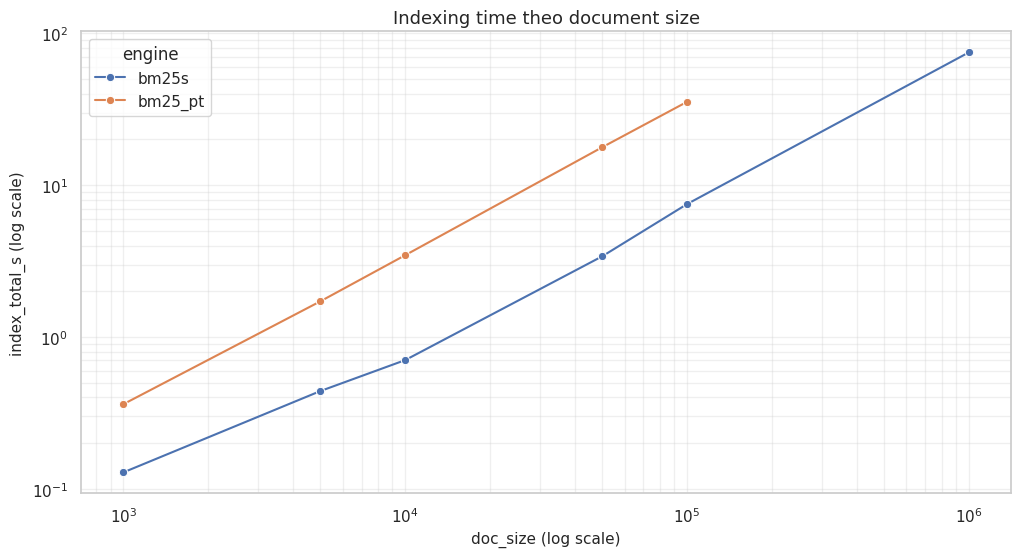

In [37]:

# Index time theo doc_size
index_df = df.drop_duplicates(["engine", "doc_size"])

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=index_df,
    x="doc_size",
    y="index_total_s",
    hue="engine",
    marker="o",
)
plt.xscale("log")
plt.yscale("log")
plt.title("Indexing time theo document size")
plt.xlabel("doc_size (log scale)")
plt.ylabel("index_total_s (log scale)")
plt.grid(True, which="both", alpha=0.3)
plt.show()


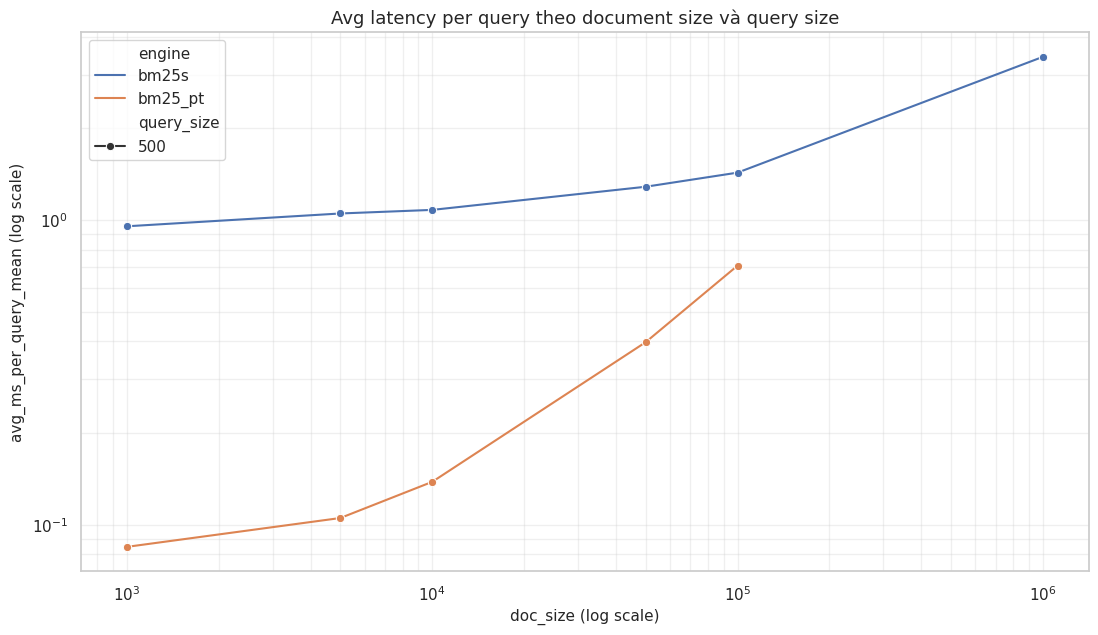

In [38]:

# Search latency trung bình / query theo doc_size, tách theo query_size
plt.figure(figsize=(13, 7))
sns.lineplot(
    data=df,
    x="doc_size",
    y="avg_ms_per_query_mean",
    hue="engine",
    style="query_size",
    markers=True,
    dashes=False,
)
plt.xscale("log")
plt.yscale("log")
plt.title("Avg latency per query theo document size và query size")
plt.xlabel("doc_size (log scale)")
plt.ylabel("avg_ms_per_query_mean (log scale)")
plt.grid(True, which="both", alpha=0.3)
plt.show()


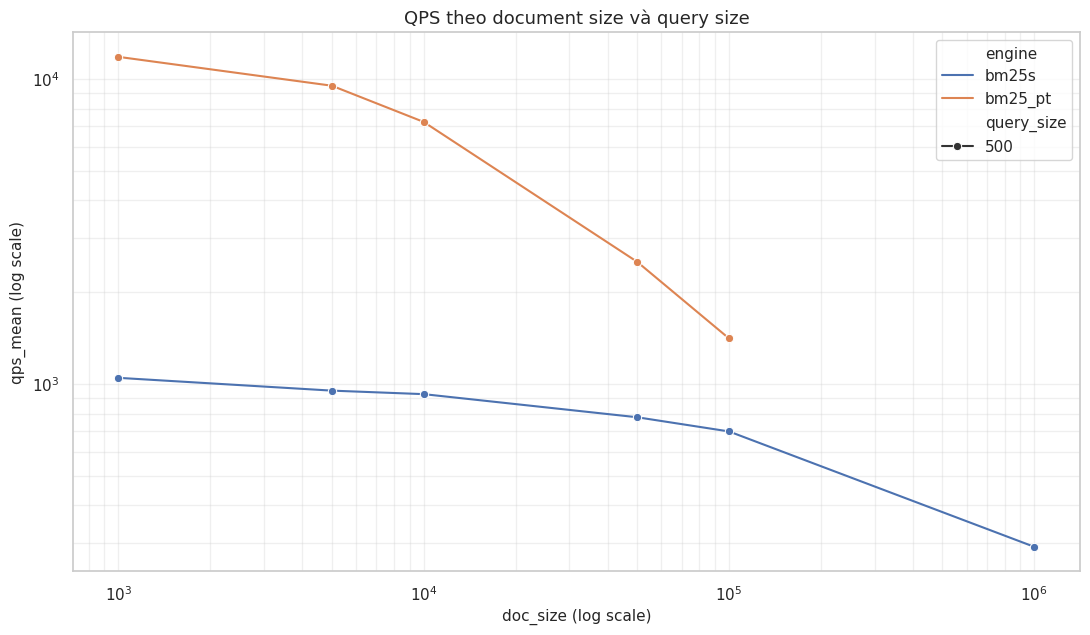

In [39]:

# Throughput QPS theo doc_size
plt.figure(figsize=(13, 7))
sns.lineplot(
    data=df,
    x="doc_size",
    y="qps_mean",
    hue="engine",
    style="query_size",
    markers=True,
    dashes=False,
)
plt.xscale("log")
plt.yscale("log")
plt.title("QPS theo document size và query size")
plt.xlabel("doc_size (log scale)")
plt.ylabel("qps_mean (log scale)")
plt.grid(True, which="both", alpha=0.3)
plt.show()


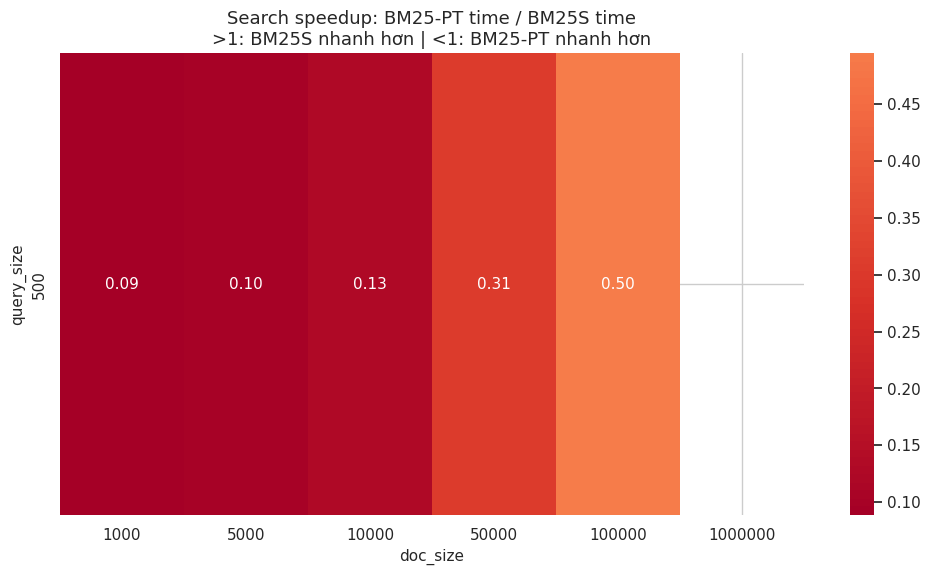

In [40]:

# Heatmap speedup search: >1 nghĩa là BM25S nhanh hơn
heat = search_pivot.pivot(
    index="query_size",
    columns="doc_size",
    values="speedup_bm25s_vs_bm25pt",
)

plt.figure(figsize=(12, 6))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdYlGn", center=1.0)
plt.title("Search speedup: BM25-PT time / BM25S time\n>1: BM25S nhanh hơn | <1: BM25-PT nhanh hơn")
plt.xlabel("doc_size")
plt.ylabel("query_size")
plt.show()


---
## 9. Bảng kết luận tự động


In [41]:

summary_rows = []

for _, row in index_pivot.iterrows():
    summary_rows.append({
        "phase": "index",
        "doc_size": int(row["doc_size"]),
        "query_size": np.nan,
        "winner": row["winner_index"],
        "speedup_bm25s_vs_bm25pt": row["speedup_index_bm25s_vs_bm25pt"],
    })

for _, row in search_pivot.iterrows():
    summary_rows.append({
        "phase": "search",
        "doc_size": int(row["doc_size"]),
        "query_size": int(row["query_size"]),
        "winner": row["winner_search"],
        "speedup_bm25s_vs_bm25pt": row["speedup_bm25s_vs_bm25pt"],
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print("📌 Diễn giải nhanh:")
print("- speedup_bm25s_vs_bm25pt > 1: BM25S nhanh hơn.")
print("- speedup_bm25s_vs_bm25pt < 1: BM25-PT nhanh hơn.")
print("- Nếu BM25-PT chạy CUDA còn BM25S chạy CPU, hãy báo cáo đây là so sánh engine+hardware, không phải CPU-CPU thuần.")


,phase,doc_size,query_size,winner,speedup_bm25s_vs_bm25pt
0,index,1000,NaN,bm25s,2.812089
1,index,5000,NaN,bm25s,3.898337
2,index,10000,NaN,bm25s,4.905696
3,index,50000,NaN,bm25s,5.224541
4,index,100000,NaN,bm25s,4.712252
5,index,1000000,NaN,bm25_pt,NaN
6,search,1000,500.0,bm25_pt,0.088612
7,search,5000,500.0,bm25_pt,0.100030
8,search,10000,500.0,bm25_pt,0.127991
9,search,50000,500.0,bm25_pt,0.308765


📌 Diễn giải nhanh:
- speedup_bm25s_vs_bm25pt > 1: BM25S nhanh hơn.
- speedup_bm25s_vs_bm25pt < 1: BM25-PT nhanh hơn.
- Nếu BM25-PT chạy CUDA còn BM25S chạy CPU, hãy báo cáo đây là so sánh engine+hardware, không phải CPU-CPU thuần.


---
## 10. Mở rộng: benchmark theo độ dài query

Nếu bạn muốn `query_size` mang nghĩa **độ dài query theo token** thay vì **số lượng query trong batch**, có thể group queries theo số token rồi benchmark từng bucket.

Ví dụ:

```python
query_len_df = pd.DataFrame({
    "query_id": all_query_ids,
    "query": all_query_texts,
})
query_len_df["query_len_ws"] = query_len_df["query"].str.split().str.len()
query_len_df["len_bucket"] = pd.cut(
    query_len_df["query_len_ws"],
    bins=[0, 3, 6, 10, 20, 100],
    labels=["1-3", "4-6", "7-10", "11-20", ">20"],
)
```

Sau đó lấy cùng số lượng query trong mỗi bucket, ví dụ 50 queries/bucket, rồi chạy lại `search_bm25s` và `search_bm25pt` trên từng bucket. Cách này trả lời câu hỏi: *query càng dài thì latency thay đổi như thế nào?*
